# 04. Analysis and Visualization

This notebook analyzes the **Developer Supply** side by using the aggregated data from **StackOverflow** and **GitHub** (filtered from the unified dataset).

## Goals
1.  Load the unified `merged_supply_data.csv`.
2.  Filter for Supply data (exclude Job postings).
3.  Analyze the distribution of domains (e.g., Web Backend, Data AI).
4.  Analyze the popularity of programming languages/technologies within each domain.
5.  Visualize trends over time.

In [13]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [14]:
# Load Unified Data
df_all = pd.read_csv('data/outputs/merged_supply_data.csv')

# Filter for Supply Data (StackOverflow + GitHub)
# source_type is 'stackoverflow', 'github', or 'job'
df_supply = df_all[df_all['source_type'] != 'job'].copy()

print(f"Total Rows: {len(df_all)}")
print(f"Supply Rows (SO + GitHub): {len(df_supply)}")
df_supply.head()

Total Rows: 26268
Supply Rows (SO + GitHub): 19211


,source_type,language,event_date,label_gpt
0,stackoverflow,go,2025,web backend
1,stackoverflow,c#,2025,developer tools
2,stackoverflow,typescript,2025,data_ai
3,stackoverflow,perl,2025,web backend
4,stackoverflow,dart,2024,web frontend


## 2. Analysis: Domain Distribution
What domains are developers most active in?

/tmp/ipykernel_15848/3153879.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, palette='viridis')


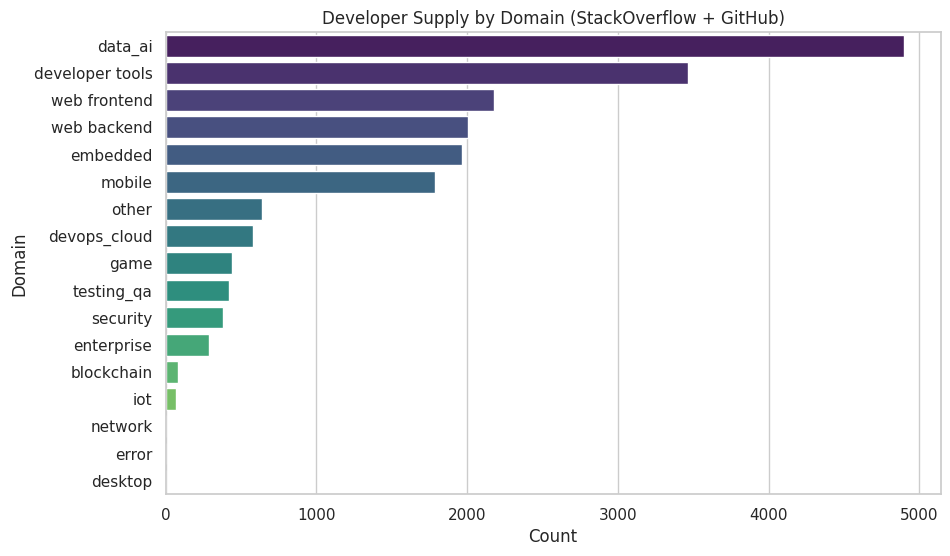

In [15]:
domain_counts = df_supply['label_gpt'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.values, y=domain_counts.index, palette='viridis')
plt.title('Developer Supply by Domain (StackOverflow + GitHub)')
plt.xlabel('Count')
plt.ylabel('Domain')
plt.show()

## 3. Analysis: Languages per Domain
What languages are dominating each domain?

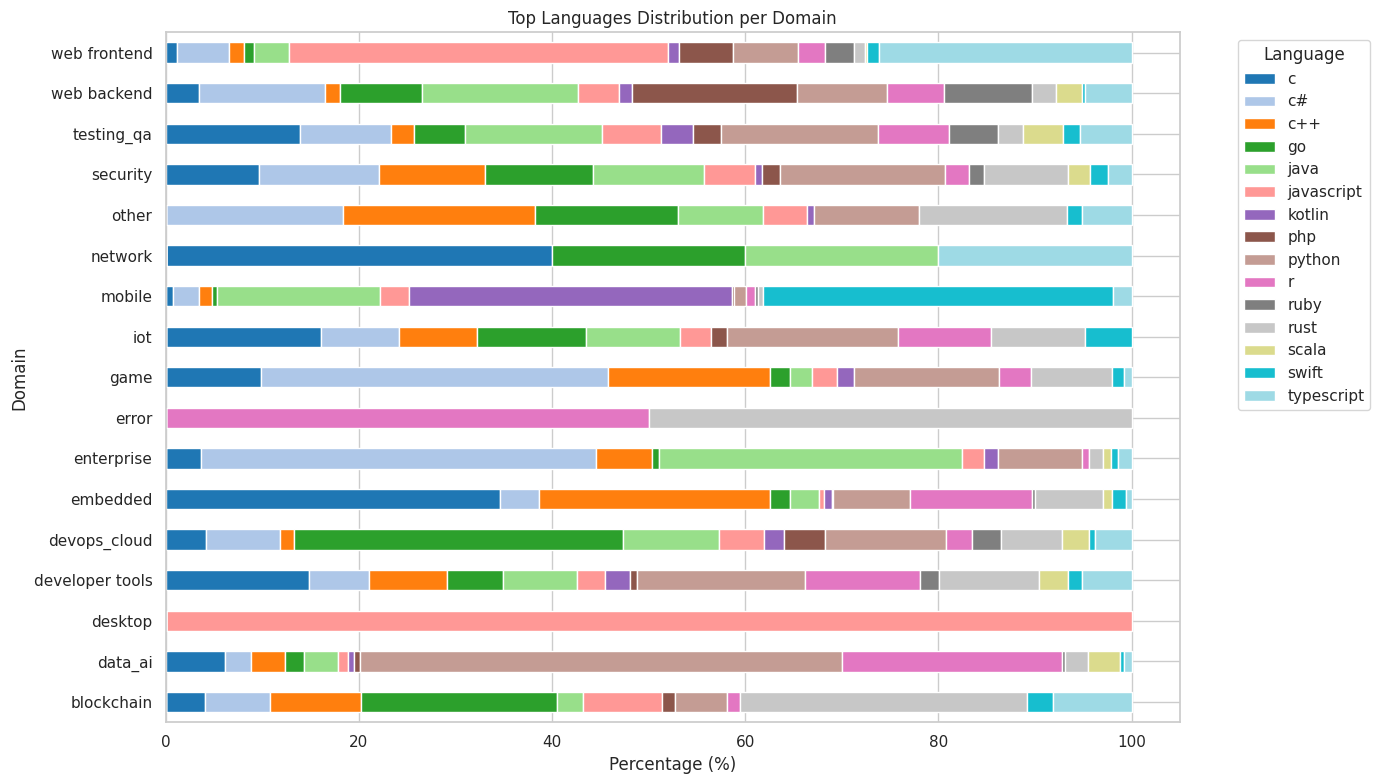

In [16]:
# Filter for top languages to keep charts readable
top_langs = df_supply['language'].value_counts().nlargest(15).index
df_top = df_supply[df_supply['language'].isin(top_langs)]

# Cross-tabulation
ct = pd.crosstab(df_top['label_gpt'], df_top['language'], normalize='index') * 100

# Plot
ct.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Top Languages Distribution per Domain')
plt.xlabel('Percentage (%)')
plt.ylabel('Domain')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Trend Analysis (Over Time)
How has activity changed over the years?

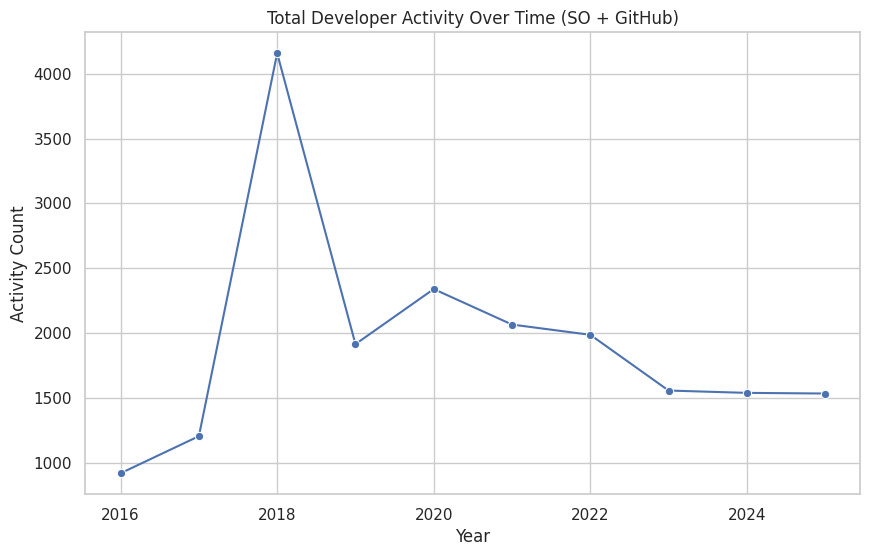

In [17]:
# Ensure event_date is treated as numeric year or string year for grouping
# The merge script standardized it to YYYY strings
df_Supply_Time = df_supply.copy()
df_Supply_Time['year'] = pd.to_numeric(df_Supply_Time['event_date'], errors='coerce')

# Drop invalid years if any
df_Supply_Time = df_Supply_Time.dropna(subset=['year'])
df_Supply_Time['year'] = df_Supply_Time['year'].astype(int)

# Count by Year
year_counts = df_Supply_Time['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Total Developer Activity Over Time (SO + GitHub)')
plt.xlabel('Year')
plt.ylabel('Activity Count')
plt.show()